# [CrisisMMD v.2](https://crisisnlp.qcri.org/crisismmd.html)


---

## A. Original description

The CrisisMMD multimodal Twitter dataset consists of several thousands of manually annotated tweets and images collected during seven major natural disasters including earthquakes, hurricanes, wildfires, and floods that happened in the year 2017 across different parts of the World. The provided datasets include three types of annotations.

Change log version 2.0: In this version of this dataset, we mapped "Not relevant or can't judge" to "Not humanitarian" for the humanitarian task. Also the "Not informative" label from informative task also mapped to "Not humanitarian" for the humanitarian task. We also removed duplicate entries that appeared while combined the tweets from different events. Both informative and humanitarian tasks are now aligned and can be useful for multitask classification learning.


#### Data format and files

The directory contains the files for different tasks:

- "task*.tsv" - training, development and test set split for the mentioned tasks.

##### Format of the TSV files under the "annotations" directory
Each TSV file in this directory contains the following columns, separated by a tab:

* event_name: corresponds to the name of the event.
* tweet_id: corresponds to the actual tweet id from Twitter.
* image_id: corresponds to a combination of a "tweet_id" and an index concatenated with an underscore. The integer indices represent different images associated with a given tweet.
* tweet_text: corresponds to the original text of a given tweet as downloaded from Twitter.
* image: corresponds to the relative path of an image inside the "data_image" folder for a given tweet.
* label: for informativeness and humanitarian tasks randomly selected labels from text and image labels; for damage task we only have a label for the image.
* label_text: corresponds to the task-specific label (i.e., informative for informativeness, infrastructure_and_utility_damage for humanitarian) assigned to a given tweet text; for the damage task, we do not provide this column.
* label_image: corresponds to the task-specific label (i.e., informative, infrastructure_and_utility_damage for humanitarian) assigned to a given tweet image; for the damage task, we do not provide this column.
* label_text_image: corresponds to the positive and negative label, which represents whether text and image labels are the same (e.g., positive) or not (e.g., negative).

### Ref
- Ferda Ofli, Firoj Alam, and Muhammad Imran, Analysis of Social Media Data using Multimodal Deep Learning for Disaster Response, In Proceedings of the 17th International Conference on Information Systems for Crisis Response and Management (ISCRAM), 2020, USA.
- Firoj Alam, Ferda Ofli, and Muhammad Imran, CrisisMMD: Multimodal Twitter Datasets from Natural Disasters, In Proceedings of the 12th International AAAI Conference on Web and Social Media (ICWSM), 2018, Stanford, California, USA.

## B. Overview

There are two folders
- crisismmd_datasplit_agreed_label
- crisismmd_datasplit_all

We consider only a subset of the original dataset where text and image pairs have the same label for a
given task, therefore, only `crisismmd_datasplit_agreed_label` is used.


** Task 1: Informative vs Not informative
   * Informative
   * Not informative

** Task 2: Humanitarian categories,

only used the data which was labeled as “informative” (i.e., either text or image was informative) in Task 1.
   * Affected individuals
   * Infrastructure and utility damage
   * Rescue, volunteering or donation effort
   * Other relevant information
   * Not humanitarian

In [68]:
from pathlib import Path
import os
import pandas as pd

import configuration
from src import dataset_settings

from dotenv import load_dotenv
load_dotenv()

dataset_path = Path(os.getenv("DATASETS_PATH")) / 'CrisisMMD' / 'V2'
base_dir = dataset_path / 'crisismmd_datasplit_agreed_label'

In [69]:
allFiles = sorted(base_dir.rglob('*.tsv'))

# Quick check of the files in the dataset
df = pd.read_csv(allFiles[0], sep='\t', encoding='utf_8')
df.head()

,event_name,tweet_id,image_id,tweet_text,image,label,label_text,label_image,label_text_image
0,california_wildfires,920329866901381123,920329866901381123_0,Family Miraculously Finds Dog They Lost When E...,data_image/california_wildfires/17_10_2017/920...,not_humanitarian,not_humanitarian,not_humanitarian,Positive
1,hurricane_irma,909744783115120640,909744783115120640_0,Hurricane Irma on #Twitter https://t.co/HDssyS...,data_image/hurricane_irma/18_9_2017/9097447831...,other_relevant_information,other_relevant_information,other_relevant_information,Positive
2,hurricane_irma,909925247331241984,909925247331241984_0,i feel attacked by jin in so many levels how t...,data_image/hurricane_irma/18_9_2017/9099252473...,not_humanitarian,not_humanitarian,not_humanitarian,Positive
3,hurricane_irma,909819142970241024,909819142970241024_0,"Post-IRMA, I can testify - SO TRUE. https://t....",data_image/hurricane_irma/18_9_2017/9098191429...,not_humanitarian,not_humanitarian,not_humanitarian,Positive
4,hurricane_maria,910526223918309376,910526223918309376_0,Hurricane Maria remains a severe threat 20 Sep...,data_image/hurricane_maria/20_9_2017/910526223...,other_relevant_information,other_relevant_information,other_relevant_information,Positive


#### Concat all files

In [70]:
metadata = {
    'hurricane_maria':{
        "country": "US",
        "event_type": "storm",
    },
    'hurricane_harvey':{
        "country": "US",
        "event_type": "storm",
    },
    'hurricane_irma':{
        "country": "US",
        "event_type": "storm",
    },
    'california_wildfires':{
        "country": "US",
        "event_type": "wildfires",
    },
    'mexico_earthquake':{
        "country": "Mexico",
        "event_type": "earthquake",
    },
    'srilanka_floods':{
        "country": "Sri Lanka",
        "event_type": "flood",
    },
    'iraq_iran_earthquake':{
        "country": "Iraq/Iran",
        "event_type": "earthquake",
    },
}

In [71]:
dfs = []
all_files = sorted(base_dir.rglob('*.tsv'))
for file in all_files:
    parent_name = file.parent.name
    # data = events_CF[parent_name]
    df = pd.read_csv(file, sep='\t', encoding='utf_8')
    df['year'] = 2017
    df['country'] = df['event_name'].apply(lambda x: metadata[x]['country'])
    df['event_type'] = df['event_name'].apply(lambda x: metadata[x]['event_type'])
    df['dataset'] = 'CrisisMMD_v.2'
    df['meta'] = df['event_name'].apply(lambda x: {
        'event_name': x,
        'file_name': file.name,
        })

    df.drop(
        columns=['label_text', 'label_image', 'label_text_image', 'image_id', 'image'],
        inplace=True)
    dfs.append(df)

df_agree = pd.concat(dfs, ignore_index=True)

In [72]:
df_agree.head()

,event_name,tweet_id,tweet_text,label,year,country,event_type,dataset,meta
0,california_wildfires,920329866901381123,Family Miraculously Finds Dog They Lost When E...,not_humanitarian,2017,US,wildfires,CrisisMMD_v.2,"{'event_name': 'california_wildfires', 'file_n..."
1,hurricane_irma,909744783115120640,Hurricane Irma on #Twitter https://t.co/HDssyS...,other_relevant_information,2017,US,storm,CrisisMMD_v.2,"{'event_name': 'hurricane_irma', 'file_name': ..."
2,hurricane_irma,909925247331241984,i feel attacked by jin in so many levels how t...,not_humanitarian,2017,US,storm,CrisisMMD_v.2,"{'event_name': 'hurricane_irma', 'file_name': ..."
3,hurricane_irma,909819142970241024,"Post-IRMA, I can testify - SO TRUE. https://t....",not_humanitarian,2017,US,storm,CrisisMMD_v.2,"{'event_name': 'hurricane_irma', 'file_name': ..."
4,hurricane_maria,910526223918309376,Hurricane Maria remains a severe threat 20 Sep...,other_relevant_information,2017,US,storm,CrisisMMD_v.2,"{'event_name': 'hurricane_maria', 'file_name':..."


In [73]:
df_agree.shape

(20787, 9)

In [74]:
df_agree['label'].value_counts()

label
informative                               8431
not_humanitarian                          4277
not_informative                           4277
other_relevant_information                1753
rescue_volunteering_or_donation_effort    1187
infrastructure_and_utility_damage          773
affected_individuals                        89
Name: count, dtype: int64

In [75]:
humanitarian_cat = [
    'other_relevant_information',
    'rescue_volunteering_or_donation_effort',
    'infrastructure_and_utility_damage',
    'affected_individuals'     
]
humanitarian_ids = df_agree[df_agree['label'].isin(humanitarian_cat)]['tweet_id'].tolist()
informative_ids = df_agree[~df_agree['tweet_id'].isin(humanitarian_ids)]['tweet_id'].tolist()

# Check if the humanitarian and informative ids are overlapping
overlap_ids = set(humanitarian_ids).intersection(set(informative_ids))
print(f'Number of overlapping ids: {len(overlap_ids)}')

Number of overlapping ids: 0


In [76]:
df_agree['relevant'] = df_agree['label'].apply(lambda x: False if x in ['not_humanitarian', 'not_informative'] else True)
df_agree.rename(columns={'label': 'original_label'}, inplace=True)
df_agree = df_agree[dataset_settings.dataset_extended_cols]
df_agree.head()

,tweet_id,tweet_text,relevant,event_type,event_name,dataset,original_label,country,year,meta
0,920329866901381123,Family Miraculously Finds Dog They Lost When E...,False,wildfires,california_wildfires,CrisisMMD_v.2,not_humanitarian,US,2017,"{'event_name': 'california_wildfires', 'file_n..."
1,909744783115120640,Hurricane Irma on #Twitter https://t.co/HDssyS...,True,storm,hurricane_irma,CrisisMMD_v.2,other_relevant_information,US,2017,"{'event_name': 'hurricane_irma', 'file_name': ..."
2,909925247331241984,i feel attacked by jin in so many levels how t...,False,storm,hurricane_irma,CrisisMMD_v.2,not_humanitarian,US,2017,"{'event_name': 'hurricane_irma', 'file_name': ..."
3,909819142970241024,"Post-IRMA, I can testify - SO TRUE. https://t....",False,storm,hurricane_irma,CrisisMMD_v.2,not_humanitarian,US,2017,"{'event_name': 'hurricane_irma', 'file_name': ..."
4,910526223918309376,Hurricane Maria remains a severe threat 20 Sep...,True,storm,hurricane_maria,CrisisMMD_v.2,other_relevant_information,US,2017,"{'event_name': 'hurricane_maria', 'file_name':..."


In [77]:
df_agree# TODO: Clean for duplicates in the 'tweet_text' column.
print(f"Number of duplicate tweets: {df_agree['tweet_text'].duplicated().sum()}")

# # Remove duplicates
# df_agree = df_agree.drop_duplicates(subset=['tweet_text'])

df_agree['tweet_text'].value_counts().head(20)

Number of duplicate tweets: 9387


tweet_text
#DryTortugus #keywest #Irma Thoughts with everyone down south. Great memories of Ft Jefferson and KW this Spring. https://t.co/8nOgmOxuVw      8
And @MariaSharapova and @MonicaAce93 are off to Puerto Rico âœˆï¸á¼Ÿ5á¼Ÿ7â¤ï¸á¾‘7 https://t.co/ltdNE4iIIW                                   8
Packed some trucks for Hurricane Maria victims today. @youthuwrc @UWRockland https://t.co/Y4GId09SgJ                                           8
Hundred earthquake victim families in Khanaqin city of Iraq were received food support today. https://t.co/VJxUr1yTYo                          8
RT @Pirates: This morning our crew is getting ready to leave for Puerto Rico. https://t.co/dc66o1x2wt                                          8
Pak Navy continues Humanitarian Assistance and Disaster Relief Operations in Flood Stricken Sri Lanka. RESPECT https://t.co/LzDAR9i17Z         8
RT @hstylespr: Thank you so much @Harry_Styles!! Puerto Rico loves you!!â¤ï¸á¼Ÿ5á¼Ÿ7á½¢2á½¢5 - R https://t.co/dqRWzcj

In [78]:
df_agree['relevant'].value_counts()

relevant
True     12233
False     8554
Name: count, dtype: int64

In [79]:
import csv
df_agree.to_csv('datasets/CrisisMMD_v2.csv', index=False, quoting=csv.QUOTE_ALL)

#### Verifying

In [80]:
df_agree.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 20787 entries, 0 to 20786
Data columns (total 10 columns):
 #   Column          Non-Null Count  Dtype 
---  ------          --------------  ----- 
 0   tweet_id        20787 non-null  int64 
 1   tweet_text      20787 non-null  object
 2   relevant        20787 non-null  bool  
 3   event_type      20787 non-null  object
 4   event_name      20787 non-null  object
 5   dataset         20787 non-null  object
 6   original_label  20787 non-null  object
 7   country         20787 non-null  object
 8   year            20787 non-null  int64 
 9   meta            20787 non-null  object
dtypes: bool(1), int64(2), object(7)
memory usage: 1.4+ MB


In [81]:
df_agree.describe(include='all')

,tweet_id,tweet_text,relevant,event_type,event_name,dataset,original_label,country,year,meta
count,2.078700e+04,20787,20787,20787,20787,20787,20787,20787,20787.0,20787
unique,NaN,11400,2,4,7,1,7,4,NaN,42
top,NaN,#DryTortugus #keywest #Irma Thoughts with ever...,True,storm,hurricane_maria,CrisisMMD_v.2,informative,US,NaN,"{'event_name': 'hurricane_maria', 'file_name':..."
freq,NaN,8,12233,15070,5329,20787,8431,16776,NaN,2374
mean,9.099229e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.0,NaN
std,1.230524e+16,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN
min,8.699189e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.0,NaN
25%,9.065887e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.0,NaN
50%,9.101189e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.0,NaN
75%,9.160028e+17,NaN,NaN,NaN,NaN,NaN,NaN,NaN,2017.0,NaN


In [82]:
# TODO: Clean for duplicates in the 'tweet_text' column.
print(f"Number of duplicate tweets: {df_agree['tweet_text'].duplicated().sum()}")

# # Remove duplicates
# df_agree = df_agree.drop_duplicates(subset=['tweet_text'])

df_agree['tweet_text'].value_counts()

Number of duplicate tweets: 9387


tweet_text
#DryTortugus #keywest #Irma Thoughts with everyone down south. Great memories of Ft Jefferson and KW this Spring. https://t.co/8nOgmOxuVw    8
And @MariaSharapova and @MonicaAce93 are off to Puerto Rico âœˆï¸á¼Ÿ5á¼Ÿ7â¤ï¸á¾‘7 https://t.co/ltdNE4iIIW                                 8
Packed some trucks for Hurricane Maria victims today. @youthuwrc @UWRockland https://t.co/Y4GId09SgJ                                         8
Hundred earthquake victim families in Khanaqin city of Iraq were received food support today. https://t.co/VJxUr1yTYo                        8
RT @Pirates: This morning our crew is getting ready to leave for Puerto Rico. https://t.co/dc66o1x2wt                                        8
                                                                                                                                            ..
Leaving a Condemned Mexico City Building https://t.co/qxBFLoReIE #SocialMedia https://t.co/fC7z1hpzGa                              

<Axes: xlabel='event_type'>

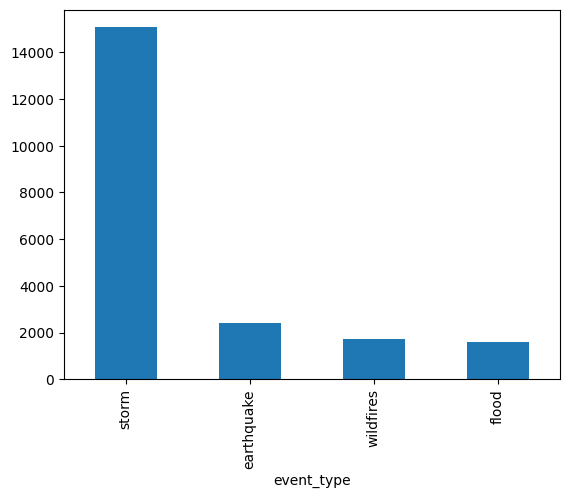

In [83]:
df_agree['event_type'].value_counts().plot(kind='bar')

<Axes: xlabel='relevant'>

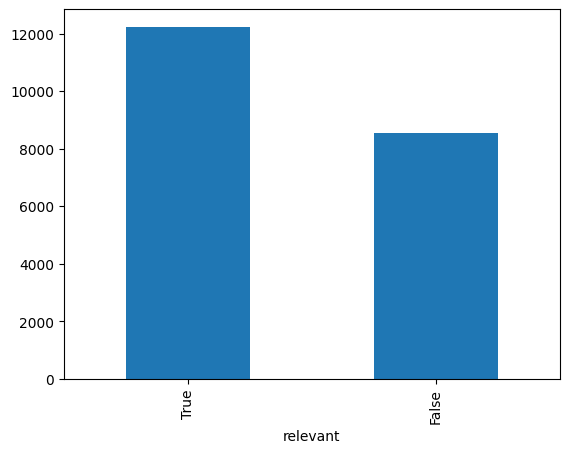

In [84]:
# TODO: Check why relevant are all False

df_agree['relevant'].value_counts().plot(kind='bar')